# Compare A Review DB Against Brayden Candidates

This notebook compares a MALCA review database against the built-in Brayden validation candidate list.

It:
- loads Brayden candidates from `malca.evaluation.validation.DEFAULT_CANDIDATES`
- loads a review DB from SQLite (`candidates` plus any merged `reviews` columns)
- matches Brayden `source_id` values to DB `asas_sn_id` values
- summarizes present vs missing targets and displays the overlap tables


In [1]:
from __future__ import annotations

from pathlib import Path
import sys


def find_repo_root(start: Path) -> Path:
    for candidate in [start, *start.parents]:
        if (candidate / "pyproject.toml").exists():
            return candidate
    raise FileNotFoundError("Could not find repo root (missing pyproject.toml).")


REPO_ROOT = find_repo_root(Path.cwd().resolve())
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

REPO_ROOT


PosixPath('/Users/calder/code/malca')

In [2]:
# Set this to the DB you want to compare.
DB_PATH = REPO_ROOT / "output/runs/runs_march18_bundle_all/review/review.taxonomy_filled.db"
DB_PATH


PosixPath('/Users/calder/code/malca/output/runs/runs_march18_bundle_all/review/review.taxonomy_filled.db')

In [3]:
import pandas as pd
from IPython.display import display

from malca.evaluation.validation import DEFAULT_CANDIDATES
from malca.review.eda_data import load_review_db

brayden_df = pd.DataFrame(DEFAULT_CANDIDATES).copy()
brayden_df["source_id"] = brayden_df["source_id"].astype(str)

db_df = load_review_db(DB_PATH).copy()
db_df["asas_sn_id"] = db_df["asas_sn_id"].astype(str)

print(f"Brayden candidates: {len(brayden_df):,}")
print(f"DB candidates: {len(db_df):,}")


Brayden candidates: 29
DB candidates: 9,569


In [4]:
db_cols = [
    "candidate_id",
    "asas_sn_id",
    "dip_significant",
    "jump_significant",
    "dipper_score",
    "status",
    "interest_score",
    "event_class",
    "reviewer",
    "updated_at",
]
db_cols = [col for col in db_cols if col in db_df.columns]

comparison = brayden_df.merge(
    db_df[db_cols].drop_duplicates(subset=["asas_sn_id"]),
    left_on="source_id",
    right_on="asas_sn_id",
    how="left",
    indicator=True,
)
comparison["in_db"] = comparison["_merge"].eq("both")

summary = (
    comparison.groupby(["category", "in_db"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[False, True], fill_value=0)
    .rename(columns={False: "missing_from_db", True: "present_in_db"})
    .sort_index()
)
summary["total"] = summary.sum(axis=1)
summary["fraction_present"] = summary["present_in_db"] / summary["total"]

overall = pd.Series(
    {
        "brayden_total": len(comparison),
        "present_in_db": int(comparison["in_db"].sum()),
        "missing_from_db": int((~comparison["in_db"]).sum()),
        "fraction_present": float(comparison["in_db"].mean()),
    }
)

display(summary)
display(overall.to_frame("value"))


in_db,missing_from_db,present_in_db,total,fraction_present
category,,,,
Dippers,9,1,10,0.1
Multiple Eclipse Binaries,6,0,6,0.0
Single Eclipse Binaries,13,0,13,0.0


,value
brayden_total,29.000000
present_in_db,1.000000
missing_from_db,28.000000
fraction_present,0.034483


In [5]:
matched_cols = [
    "source",
    "source_id",
    "category",
    "mag_bin",
    "search_method",
    "expected_detected",
    "candidate_id",
    "dipper_score",
    "dip_significant",
    "jump_significant",
    "status",
    "interest_score",
    "event_class",
]
matched_cols = [col for col in matched_cols if col in comparison.columns]

matched = comparison.loc[comparison["in_db"], matched_cols].sort_values(["category", "source_id"])
matched


,source,source_id,category,mag_bin,search_method,expected_detected,candidate_id,dipper_score,dip_significant,jump_significant,status,interest_score,event_class
4,J184916-473251,472447294641,Dippers,13_13.5,Known,True,472447294641,22.856494,1.0,0.0,NaN,NaN,NaN


In [6]:
missing_cols = [
    "source",
    "source_id",
    "category",
    "mag_bin",
    "search_method",
    "expected_detected",
]
missing_cols = [col for col in missing_cols if col in comparison.columns]

missing = comparison.loc[~comparison["in_db"], missing_cols].sort_values(["category", "source_id"])
missing


,source,source_id,category,mag_bin,search_method,expected_detected
2,J174328+343315,223339338105,Dippers,13_13.5,Pipeline,True
6,J070519+061219,266288137752,Dippers,13.5_14,Known,False
8,J085816-430955,352187470767,Dippers,12_12.5,Known,False
0,J042214+152530,377957522430,Dippers,13_13.5,Pipeline,True
1,J202402+383938,42950993887,Dippers,13_13.5,Pipeline,True
5,J183153-284827,455267102087,Dippers,13.5_14,Known,False
7,J081523-385923,532576686103,Dippers,13.5_14,Known,False
3,J080327-261620,601296043597,Dippers,13_13.5,Pipeline,False
9,J114712-621037,609886184506,Dippers,13_13.5,Known,False
13,J175912-120956,326417831663,Multiple Eclipse Binaries,13_13.5,Pipeline,True


In [7]:
expected = comparison.loc[comparison["expected_detected"].fillna(False)].copy()

expected_summary = (
    expected.groupby(["category", "in_db"])
    .size()
    .unstack(fill_value=0)
    .reindex(columns=[False, True], fill_value=0)
    .rename(columns={False: "missing_expected", True: "present_expected"})
    .sort_index()
)
expected_summary["total_expected"] = expected_summary.sum(axis=1)

display(expected_summary)
print(f"Expected-detected Brayden targets present in DB: {int(expected['in_db'].sum())}/{len(expected)}")


in_db,missing_expected,present_expected,total_expected
category,,,
Dippers,3,1,4
Multiple Eclipse Binaries,5,0,5
Single Eclipse Binaries,12,0,12


Expected-detected Brayden targets present in DB: 1/21


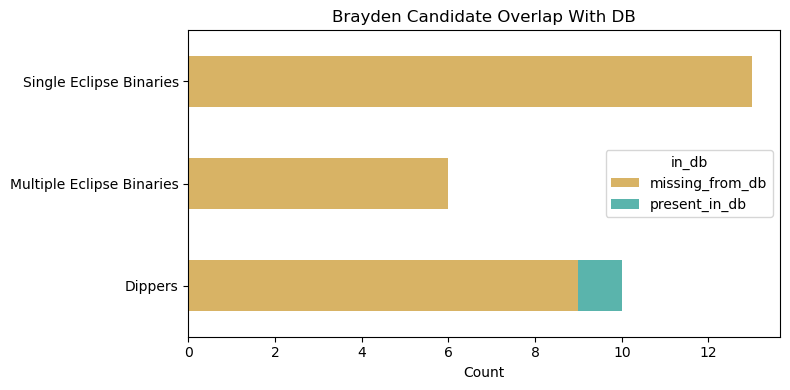

In [8]:
import matplotlib.pyplot as plt

plot_df = summary[["missing_from_db", "present_in_db"]]
ax = plot_df.plot(
    kind="barh",
    stacked=True,
    figsize=(8, 4),
    color=["#d8b365", "#5ab4ac"],
)
ax.set_xlabel("Count")
ax.set_ylabel("")
ax.set_title("Brayden Candidate Overlap With DB")
plt.tight_layout()
plt.show()
